In [160]:
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [161]:
train_dataset = pd.read_csv("../datasets/train_dataset_exp.csv")
test_dataset = pd.read_csv("../datasets/test_dataset_exp.csv")

In [162]:
train_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 35 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   property_id                 200000 non-null  str    
 1   Unnamed: 1                  200000 non-null  int64  
 2   date                        200000 non-null  str    
 3   location_score              200000 non-null  int64  
 4   amenities_score             200000 non-null  int64  
 5   rating                      200000 non-null  float64
 6   base_price                  200000 non-null  float64
 7   month                       200000 non-null  int64  
 8   weekend                     200000 non-null  int64  
 9   holiday                     200000 non-null  int64  
 10  demand                      200000 non-null  float64
 11  competitor_price            200000 non-null  float64
 12  nearby_event                200000 non-null  int64  
 13  market_trend             

In [163]:
train_valid_idx = train_dataset.dropna().index

train_dataset = train_dataset.loc[train_valid_idx]

test_valid_idx = test_dataset.dropna().index

test_dataset = test_dataset.loc[test_valid_idx]

In [164]:
train_dataset['date'] = pd.to_datetime(train_dataset['date'])
test_dataset['date'] = pd.to_datetime(test_dataset['date'])

In [165]:
X_train = train_dataset.drop(
  columns=[
    'property_id',
    'date',
    'revenue',
    'occupancy_rate',
    'Unnamed: 1',
    'occupancy_lag_1',
    'price_lag_1',
    'demand_lag_1',
    'rolling_7_day_demand',
    'rolling_30_day_price'
  ]
)

y_train = train_dataset['occupancy_rate']

X_test = test_dataset.drop(
  columns=[
    'property_id',
    'date',
    'revenue',
    'occupancy_rate',
    'Unnamed: 1',
    'occupancy_lag_1',
    'price_lag_1',
    'demand_lag_1',
    'rolling_7_day_demand',
    'rolling_30_day_price'
  ]
)

y_test = test_dataset['occupancy_rate']

X_train.columns = (
    X_train.columns
    .str.replace(' ', '_')
    .str.replace(r'[^A-Za-z0-9_]', '', regex=True)
)

X_test.columns = (
    X_test.columns
    .str.replace(' ', '_')
    .str.replace(r'[^A-Za-z0-9_]', '', regex=True)
)

train_valid_idx = X_train.dropna().index

X_train = X_train.loc[train_valid_idx]
y_train = y_train.loc[train_valid_idx]

test_valid_idx = X_test.dropna().index

X_test = X_test.loc[test_valid_idx]
y_test = y_test.loc[test_valid_idx]

In [166]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 199500 entries, 1 to 199999
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   location_score              199500 non-null  int64  
 1   amenities_score             199500 non-null  int64  
 2   rating                      199500 non-null  float64
 3   base_price                  199500 non-null  float64
 4   month                       199500 non-null  int64  
 5   weekend                     199500 non-null  int64  
 6   holiday                     199500 non-null  int64  
 7   demand                      199500 non-null  float64
 8   competitor_price            199500 non-null  float64
 9   nearby_event                199500 non-null  int64  
 10  market_trend                199500 non-null  float64
 11  final_price                 199500 non-null  float64
 12  season_Monsoon              199500 non-null  int64  
 13  season_Summer               19

In [167]:
model = LGBMRegressor(max_depth=6)
model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003996 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1291
[LightGBM] [Info] Number of data points in the train set: 199500, number of used features: 25
[LightGBM] [Info] Start training from score 0.647961


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [168]:
preds = np.array(model.predict(X_test))

In [169]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_true=y_test,y_pred=preds)
mse = mean_squared_error(y_true=y_test,y_pred=preds)
r2_scr = r2_score(y_true=y_test,y_pred=preds)
print(f"Mean Aboslute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2_scr}")

Mean Aboslute Error: 0.01518081833948596
Mean Squared Error: 0.0004807687064861598
R2 Score: 0.991116985955343


In [170]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

print(importance_df.head(15))

                       feature  importance
8             competitor_price        1231
11                 final_price        1149
1              amenities_score         148
3                   base_price         138
0               location_score         134
2                       rating         102
7                       demand          84
10                market_trend           6
23  property_type_Luxury_suite           4
24  property_type_Private_room           2
21           weekday_Wednesday           2
4                        month           0
6                      holiday           0
5                      weekend           0
13               season_Summer           0


In [171]:
import joblib

joblib.dump(
  model,
  "../models/lightgbm_api_model_exp.pkl"
)

['../models/lightgbm_api_model_exp.pkl']

In [172]:
import numpy as np
import pandas as pd

def predict_prices_batch(model, test_dataset: pd.DataFrame, max_price_steps=50):
    N = len(test_dataset)  
    M = max_price_steps    
    
    df_expanded = test_dataset.loc[test_dataset.index.repeat(M)].copy()
    
    price_increments = np.tile(np.arange(M) * 5, N)
    df_expanded['final_price'] = df_expanded['base_price'] + price_increments
    
    predicted_occupancies = model.predict(df_expanded)
    
    prices_matrix = df_expanded['final_price'].values.reshape(N, M)
    occupancy_matrix = predicted_occupancies.reshape(N, M)
    
    revenue_matrix = prices_matrix * occupancy_matrix
    
    best_indices = np.argmax(revenue_matrix, axis=1)
    best_prices = prices_matrix[np.arange(N), best_indices]
    
    max_revenues = np.max(revenue_matrix, axis=1)
    
    return best_prices.tolist(), max_revenues.tolist()

In [173]:
best_prices, max_optim_revenues = predict_prices_batch(model,X_test)

In [174]:
price_comparison_df = pd.DataFrame({
  'original_prices': X_test['final_price'],
  'original_competitor_prices': X_test['competitor_price'],
  'original_revenue': test_dataset['revenue'],
  'optimised_revenue_calculated': max_optim_revenues,
  'model_optimised_prices': best_prices
})
price_comparison_df.to_csv('../optimizations/optimized_prices.csv')

In [175]:
test_dataset['optimized_revenue'] = max_optim_revenues
original_monthly_revenue = (
  test_dataset
  .groupby(test_dataset['date'].dt.month)['revenue']
  .mean() 
)

optimised_monthly_revenue = (
  test_dataset
  .groupby(test_dataset['date'].dt.month)['optimized_revenue']
  .mean()
)

comparison_df = pd.DataFrame({
    'Original Revenue': original_monthly_revenue,
    'Optimized Revenue': optimised_monthly_revenue
})

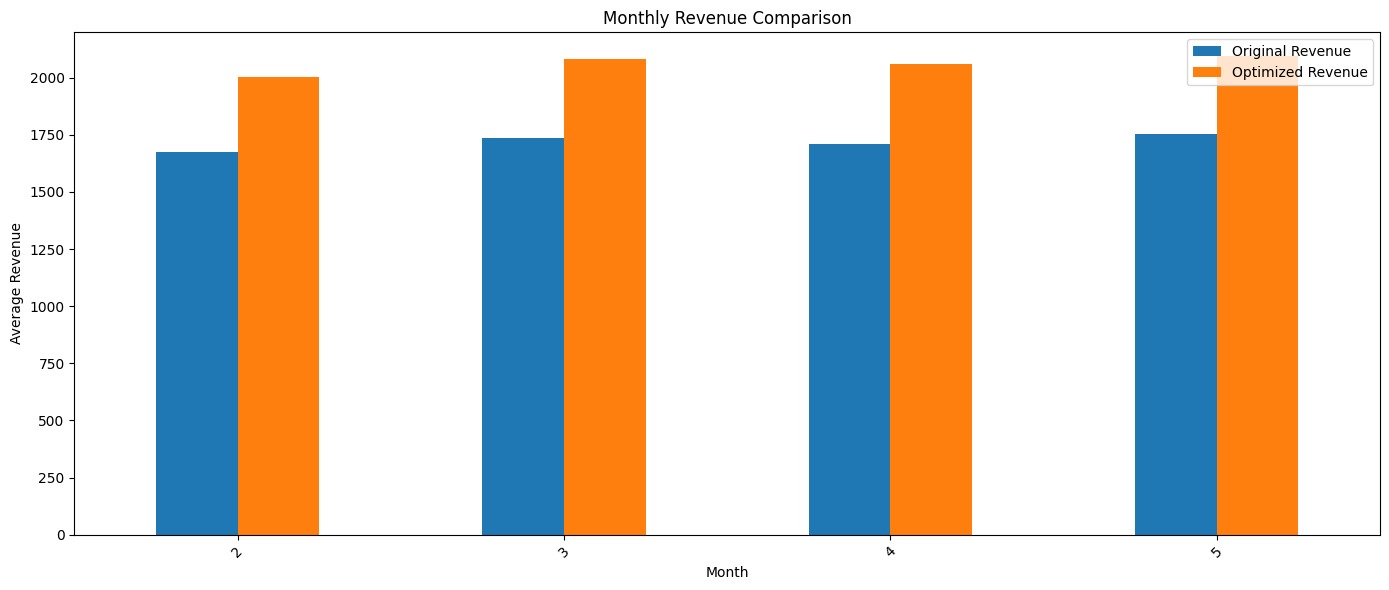

In [176]:
comparison_df.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title(
    'Monthly Revenue Comparison'
)

plt.ylabel('Average Revenue')

plt.xlabel('Month')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [177]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [178]:
preds_xgb = np.array(model_xgb.predict(X_test))

In [179]:
mae_xgb = mean_absolute_error(y_true=y_test,y_pred=preds)
mse_xgb = mean_squared_error(y_true=y_test,y_pred=preds)
r2_scr_xgb = r2_score(y_true=y_test,y_pred=preds)
print(f"Mean Aboslute Error: {mae_xgb}")
print(f"Mean Squared Error: {mse_xgb}")
print(f"R2 Score: {r2_scr_xgb}")

Mean Aboslute Error: 0.01518081833948596
Mean Squared Error: 0.0004807687064861598
R2 Score: 0.991116985955343


In [180]:
importance_df_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

importance_df_xgb = importance_df.sort_values(
    'importance',
    ascending=False
)

print(importance_df_xgb.head(15))

                       feature  importance
8             competitor_price        1231
11                 final_price        1149
1              amenities_score         148
3                   base_price         138
0               location_score         134
2                       rating         102
7                       demand          84
10                market_trend           6
23  property_type_Luxury_suite           4
24  property_type_Private_room           2
21           weekday_Wednesday           2
4                        month           0
6                      holiday           0
5                      weekend           0
13               season_Summer           0


In [181]:
joblib.dump(
  model,
  "../models/lightgbm_api_model_exp_xgb.pkl"
)

['../models/lightgbm_api_model_exp_xgb.pkl']

In [182]:
best_prices_xgb, max_optim_revenues_xgb = predict_prices_batch(model_xgb,X_test)

In [183]:
price_comparison_df_xgb = pd.DataFrame({
  'original_prices': X_test['final_price'],
  'original_competitor_prices': X_test['competitor_price'],
  'original_revenue': test_dataset['revenue'],
  'optimised_revenue_calculated': max_optim_revenues,
  'model_optimised_prices': best_prices
})
price_comparison_df.to_csv('../optimizations/optimized_prices_xgb.csv')

PermissionError: [Errno 13] Permission denied: '../optimizations/optimized_prices_xgb.csv'